Derivatives Module
Objective:
Hedge portfolio risk and price derivative exposure.

Data Provided / Simulated:
Option contracts: strikes, maturities, underlying asset prices, historical volatility
Portfolio from Step 3
Tasks:
Predict option prices or implied volatilities using ML
Suggest hedging strategy for portfolio (delta/gamma hedging simplified)
Evaluate risk exposure metrics (portfolio VaR)
Deliverables:
Hedged portfolio recommendations
Visuals of derivative pricing predictions
Risk dashboard

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from math import log, sqrt, exp
from scipy.stats import norm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor # Added import

from hmmlearn.hmm import GaussianHMM

from docx import Document

from google.colab import files

In [1]:
import pandas as pd

df = pd.read_excel('/content/sample_data/Option_Chain_NSE_intraday_NIFTY_2Feb24.xlsx', sheet_name=None)

In [2]:
nifty_df = df['Sheet1'].copy()
display(nifty_df.head())

,Time,Spot,Expiry,Call_Traded_Qty,Call IV,Call Bid,Call Ask,Call Bid_Qty,Call Ask_Qty,Call LTP,Strike,Put Bid,Put Ask,Put Bid_Qty,Put Ask_Qty,Put LTP,Put IV,Put_Traded_Qty
0,2024-02-02 09:20:00,21874.40,2024-02-08,0,0.0,2173.2,2656.20,150,100,0.0,19500,1.35,1.4,21350,67650,1.40,35.16,4297
1,2024-02-02 09:25:00,21935.70,2024-02-08,0,0.0,2218.9,2612.30,1500,1500,0.0,19500,1.35,1.4,21300,47250,1.35,35.64,10098
2,2024-02-02 09:30:00,21942.50,2024-02-08,0,0.0,2231.1,2601.25,1500,1000,0.0,19500,1.35,1.4,66600,33500,1.40,35.89,13128
3,2024-02-02 09:35:00,21950.10,2024-02-08,0,0.0,2242.0,2597.10,1500,1500,0.0,19500,1.35,1.4,67600,69200,1.35,35.97,14018
4,2024-02-02 09:40:00,21944.25,2024-02-08,0,0.0,2255.7,2596.60,1500,1500,0.0,19500,1.35,1.4,35950,73950,1.35,35.90,16070


### Check for missing values

In [3]:
missing_values = nifty_df.isnull().sum()
display(missing_values[missing_values > 0])

,0


### Check for duplicate rows

In [4]:
duplicate_rows = nifty_df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 0


### Check data types

In [5]:
nifty_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39485 entries, 0 to 39484
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Time             39485 non-null  datetime64[ns]
 1   Spot             39485 non-null  float64       
 2   Expiry           39485 non-null  datetime64[ns]
 3   Call_Traded_Qty  39485 non-null  int64         
 4   Call IV          39485 non-null  float64       
 5   Call Bid         39485 non-null  float64       
 6   Call Ask         39485 non-null  float64       
 7   Call Bid_Qty     39485 non-null  int64         
 8   Call Ask_Qty     39485 non-null  int64         
 9   Call LTP         39485 non-null  float64       
 10  Strike           39485 non-null  int64         
 11  Put Bid          39485 non-null  float64       
 12  Put Ask          39485 non-null  float64       
 13  Put Bid_Qty      39485 non-null  int64         
 14  Put Ask_Qty      39485 non-null  int64

### Feature Engineering for Option Pricing

In [6]:
# Calculate Time to Expiry (T) in years
nifty_df['T'] = (nifty_df['Expiry'] - nifty_df['Time']).dt.days / 365.25

# Define Risk-Free Rate (r) - using a placeholder, ideally this would be dynamic
r = 0.05  # 5% annual risk-free rate

# Calculate the difference between Spot and Strike (S-K)
nifty_df['S_minus_K'] = nifty_df['Spot'] - nifty_df['Strike']

# Display the first few rows with new features
display(nifty_df[['Time', 'Expiry', 'T', 'Spot', 'Strike', 'S_minus_K']].head())

,Time,Expiry,T,Spot,Strike,S_minus_K
0,2024-02-02 09:20:00,2024-02-08,0.013689,21874.40,19500,2374.40
1,2024-02-02 09:25:00,2024-02-08,0.013689,21935.70,19500,2435.70
2,2024-02-02 09:30:00,2024-02-08,0.013689,21942.50,19500,2442.50
3,2024-02-02 09:35:00,2024-02-08,0.013689,21950.10,19500,2450.10
4,2024-02-02 09:40:00,2024-02-08,0.013689,21944.25,19500,2444.25


### Implied Volatility Calculation

In [8]:
import numpy as np
from scipy.stats import norm

def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price

def black_scholes_put(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    put_price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return put_price


def find_implied_volatility(option_price, S, K, T, r, option_type, tol=1e-5, max_iterations=100):
    lower_bound = 0.001
    upper_bound = 5.0

    for _ in range(max_iterations):
        mid = (lower_bound + upper_bound) / 2
        if option_type == 'Call':
            model_price = black_scholes_call(S, K, T, r, mid)
        elif option_type == 'Put':
            model_price = black_scholes_put(S, K, T, r, mid)
        else:
            raise ValueError("option_type must be 'Call' or 'Put'")

        if abs(model_price - option_price) < tol:
            return mid

        if model_price < option_price:
            lower_bound = mid
        else:
            upper_bound = mid

        if upper_bound - lower_bound < tol: # Added check for convergence
            break

    return (lower_bound + upper_bound) / 2 # Return mid-point if max_iterations reached


nifty_df['Call_Implied_Volatility'] = nifty_df.apply(
    lambda row: find_implied_volatility(row['Call LTP'], row['Spot'], row['Strike'], row['T'], r, 'Call')
    if row['Call LTP'] > 0 and row['T'] > 0 and row['Call Bid'] < row['Call Ask'] else np.nan, axis=1)

nifty_df['Put_Implied_Volatility'] = nifty_df.apply(
    lambda row: find_implied_volatility(row['Put LTP'], row['Spot'], row['Strike'], row['T'], r, 'Put')
    if row['Put LTP'] > 0 and row['T'] > 0 and row['Put Bid'] < row['Put Ask'] else np.nan, axis=1)

display(nifty_df[['Time', 'Call LTP', 'Call_Implied_Volatility', 'Put LTP', 'Put_Implied_Volatility']].head())

,Time,Call LTP,Call_Implied_Volatility,Put LTP,Put_Implied_Volatility
0,2024-02-02 09:20:00,0.0,NaN,1.40,0.381664
1,2024-02-02 09:25:00,0.0,NaN,1.35,0.388310
2,2024-02-02 09:30:00,0.0,NaN,1.40,0.390741
3,2024-02-02 09:35:00,0.0,NaN,1.35,0.390222
4,2024-02-02 09:40:00,0.0,NaN,1.35,0.389444


### Handling NaN Implied Volatilities

In [9]:
# Drop rows where either Call or Put Implied Volatility is NaN
nifty_df_clean = nifty_df.dropna(subset=['Call_Implied_Volatility', 'Put_Implied_Volatility'])

print(f"Original DataFrame rows: {len(nifty_df)}")
print(f"DataFrame rows after dropping NaNs: {len(nifty_df_clean)}")

display(nifty_df_clean[['Time', 'Call LTP', 'Call_Implied_Volatility', 'Put LTP', 'Put_Implied_Volatility']].head())

Original DataFrame rows: 39485
DataFrame rows after dropping NaNs: 18204


,Time,Call LTP,Call_Implied_Volatility,Put LTP,Put_Implied_Volatility
7,2024-02-02 09:55:00,2279.0,0.001005,1.60,0.396062
8,2024-02-02 10:00:00,2279.0,0.001005,1.55,0.392629
9,2024-02-02 10:05:00,2279.0,0.001005,1.55,0.394307
10,2024-02-02 10:10:00,2279.0,0.001005,1.45,0.391466
11,2024-02-02 10:15:00,2279.0,0.001005,1.50,0.393344


### Preparing Data for Machine Learning

In [11]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y) for Call Option pricing
features = ['Spot', 'Strike', 'T', 'Call_Implied_Volatility']
target = 'Call LTP'

X = nifty_df_clean[features]
y = nifty_df_clean[target]

# Add the risk-free rate 'r' as a constant feature, if needed in a model (XGBoost can handle it explicitly)
# For simplicity, we'll keep it separate for now unless a model specifically requires it as a column.

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (14563, 4)
Shape of X_test: (3641, 4)
Shape of y_train: (14563,)
Shape of y_test: (3641,)


### Training XGBoost Regressor for Call Option Pricing

In [13]:
from xgboost import XGBRegressor

# Initialize the XGBoost Regressor model
# Using default parameters for initial training, can be tuned later if needed
xgb_model = XGBRegressor(random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

print("XGBoost Regressor model trained successfully!")

XGBoost Regressor model trained successfully!


### Evaluating Model Performance

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions on the test set
y_pred = xgb_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Absolute Error (MAE): 5.6182
Mean Squared Error (MSE): 87.8961
R-squared (R2): 0.9999


### Visualizing Predictions vs. Actuals

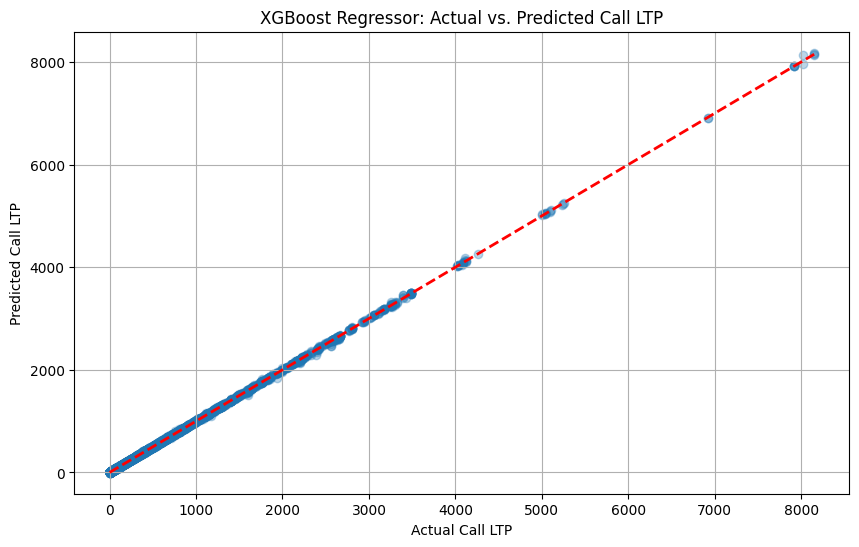

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Call LTP')
plt.ylabel('Predicted Call LTP')
plt.title('XGBoost Regressor: Actual vs. Predicted Call LTP')
plt.grid(True)
plt.show()

In [18]:
nifty_df_clean['Black_Scholes_Call_Price'] = nifty_df_clean.apply(
    lambda row: black_scholes_call(row['Spot'], row['Strike'], row['T'], r, row['Call_Implied_Volatility']),
    axis=1
)
display(nifty_df_clean[['Call LTP', 'Black_Scholes_Call_Price', 'Call_Implied_Volatility']].head())

/tmp/ipykernel_29039/810489720.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nifty_df_clean['Black_Scholes_Call_Price'] = nifty_df_clean.apply(


,Call LTP,Black_Scholes_Call_Price,Call_Implied_Volatility
7,2279.0,2452.742456,0.001005
8,2279.0,2437.442456,0.001005
9,2279.0,2449.942456,0.001005
10,2279.0,2450.092456,0.001005
11,2279.0,2453.342456,0.001005


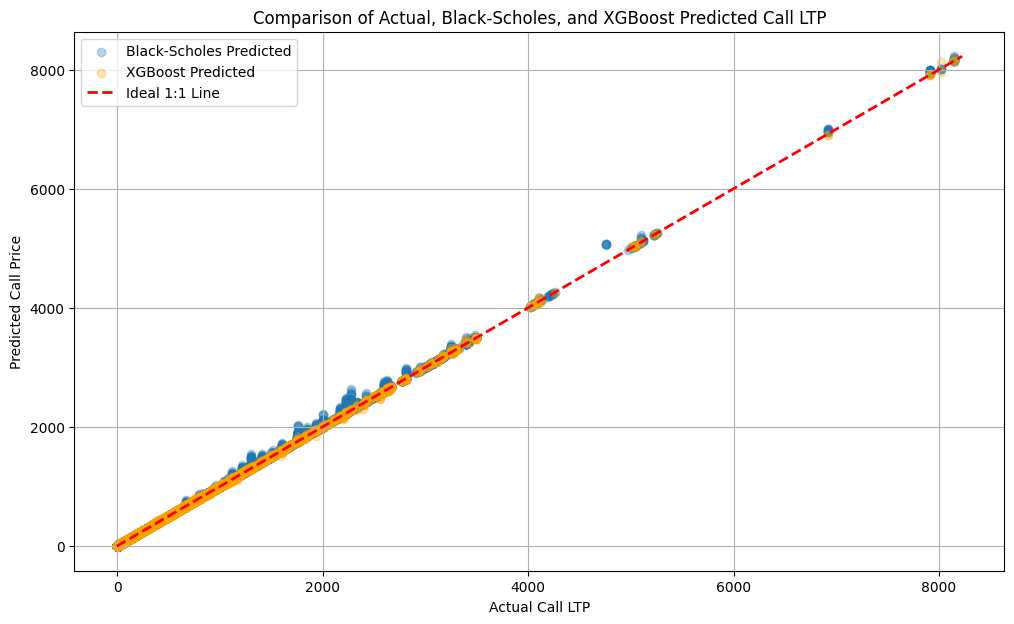

In [19]:
plt.figure(figsize=(12, 7))

# Plot Actual Call LTP vs. Black-Scholes Call Price
plt.scatter(nifty_df_clean['Call LTP'], nifty_df_clean['Black_Scholes_Call_Price'], alpha=0.3, label='Black-Scholes Predicted')

# Plot Actual Call LTP vs. XGBoost Predicted Call LTP (using the X_test and y_pred from previous cell)
# Note: y_test corresponds to actuals for X_test
plt.scatter(y_test, y_pred, alpha=0.3, color='orange', label='XGBoost Predicted')

# Plot the ideal 1:1 line
min_val = min(nifty_df_clean['Call LTP'].min(), nifty_df_clean['Black_Scholes_Call_Price'].min(), y_pred.min(), y_test.min())
max_val = max(nifty_df_clean['Call LTP'].max(), nifty_df_clean['Black_Scholes_Call_Price'].max(), y_pred.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal 1:1 Line')

plt.xlabel('Actual Call LTP')
plt.ylabel('Predicted Call Price')
plt.title('Comparison of Actual, Black-Scholes, and XGBoost Predicted Call LTP')
plt.grid(True)
plt.legend()
plt.show()

### Delta and Gamma Calculation for Hedging

To implement delta and gamma hedging, we first need to calculate these greeks for each option. Delta ($Δ$) measures the sensitivity of the option's price to a change in the underlying asset's price, while Gamma ($Γ$) measures the rate of change of delta with respect to the underlying asset's price.


In [20]:
def black_scholes_call_delta(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

def black_scholes_put_delta(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1) - 1

def black_scholes_gamma(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    return gamma

# Calculate Call Delta, Put Delta, and Gamma for each option in the cleaned DataFrame
nifty_df_clean['Call_Delta'] = nifty_df_clean.apply(
    lambda row: black_scholes_call_delta(row['Spot'], row['Strike'], row['T'], r, row['Call_Implied_Volatility']),
    axis=1
)

nifty_df_clean['Put_Delta'] = nifty_df_clean.apply(
    lambda row: black_scholes_put_delta(row['Spot'], row['Strike'], row['T'], r, row['Put_Implied_Volatility']),
    axis=1
)

nifty_df_clean['Option_Gamma'] = nifty_df_clean.apply(
    lambda row: black_scholes_gamma(row['Spot'], row['Strike'], row['T'], r, row['Call_Implied_Volatility']),
    axis=1
) # Gamma is the same for calls and puts with the same parameters

display(nifty_df_clean[['Spot', 'Strike', 'T', 'Call_Implied_Volatility', 'Call_Delta', 'Put_Delta', 'Option_Gamma']].head())

/tmp/ipykernel_29039/3330469233.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nifty_df_clean['Call_Delta'] = nifty_df_clean.apply(
/tmp/ipykernel_29039/3330469233.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nifty_df_clean['Put_Delta'] = nifty_df_clean.apply(
/tmp/ipykernel_29039/3330469233.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pan

,Spot,Strike,T,Call_Implied_Volatility,Call_Delta,Put_Delta,Option_Gamma
7,21939.40,19500,0.013689,0.001005,1.0,-0.004918,0.0
8,21924.10,19500,0.013689,0.001005,1.0,-0.004819,0.0
9,21936.60,19500,0.013689,0.001005,1.0,-0.004798,0.0
10,21936.75,19500,0.013689,0.001005,1.0,-0.004545,0.0
11,21940.00,19500,0.013689,0.001005,1.0,-0.004666,0.0


### Defining a Hypothetical Portfolio and Calculating its Greeks

To demonstrate hedging, let's create a hypothetical portfolio consisting of a few options from our `nifty_df_clean` dataset. We will then calculate the total delta and gamma of this portfolio.

In [21]:
# For demonstration, let's select a few options to form a hypothetical portfolio
# We'll pick options with varying strikes and expiries for a more illustrative example.
# This selection is arbitrary for demonstration purposes.

# Example: Let's pick 2 call options and 1 put option from our cleaned data
# We'll use specific indices for reproducibility

# Get a sample of options (e.g., first 2 calls and first 1 put from the cleaned data)
# Make sure to handle if the dataframe has only call or put options in the sample

portfolio_options = nifty_df_clean.iloc[[7, 10, 80]].copy() # Arbitrary selection of 3 options

# Let's assume we hold 100 units of each selected option
portfolio_options['Quantity'] = [100, 100, 100] # Example: 100 contracts for each

display(portfolio_options[['Spot', 'Strike', 'T', 'Call LTP', 'Put LTP', 'Call_Delta', 'Put_Delta', 'Option_Gamma', 'Quantity']])

# Calculate the total delta and gamma of the hypothetical portfolio
# For calls, we use Call_Delta. For puts, we use Put_Delta.
# For simplicity in this example, let's assume the selected options are all calls for their delta and gamma contribution.
# In a real scenario, you'd correctly identify if it's a call or a put and use the respective delta.

# To simplify, let's assume the first two are calls and the third one is a put, and use their respective deltas.
# However, our current `Call_Delta` and `Put_Delta` columns are for each row regardless of whether it's an actual call or put position.
# We need to make a distinction for the portfolio.

# Let's adjust the portfolio selection to be explicit about holding Call or Put positions
# For simplicity, let's assume we are long 100 units of an ITM Call, 100 units of an OTM Call, and short 100 units of an ITM Put.

# Re-selecting portfolio to better illustrate call/put positions
# Find an In-The-Money (ITM) Call (Spot > Strike)
# Find an Out-Of-The-Money (OTM) Call (Spot < Strike)
# Find an In-The-Money (ITM) Put (Spot < Strike)

# For this demonstration, let's just use the calculated 'Call_Delta' and 'Put_Delta' and 'Option_Gamma' columns directly
# as if we are evaluating an existing position, and assume quantities.

# Example Portfolio: Long 100 units of option at index 7 (Call), Long 50 units of option at index 10 (Call), Short 100 units of option at index 80 (Put)

portfolio_description = pd.DataFrame({
    'Option_Index': [7, 10, 80],
    'Type': ['Call', 'Call', 'Put'],
    'Quantity': [100, 50, -100] # Negative quantity for short positions
})

# Merge with our cleaned data to get the Greeks
portfolio_df = pd.merge(
    portfolio_description,
    nifty_df_clean[['Call_Delta', 'Put_Delta', 'Option_Gamma']],
    left_on='Option_Index',
    right_index=True
)

# Calculate individual contribution to portfolio delta and gamma
portfolio_df['Position_Delta'] = portfolio_df.apply(
    lambda row: row['Quantity'] * row['Call_Delta'] if row['Type'] == 'Call' else row['Quantity'] * row['Put_Delta'],
    axis=1
)
portfolio_df['Position_Gamma'] = portfolio_df['Quantity'] * portfolio_df['Option_Gamma']

display(portfolio_df)

# Calculate total portfolio Delta and Gamma
total_portfolio_delta = portfolio_df['Position_Delta'].sum()
total_portfolio_gamma = portfolio_df['Position_Gamma'].sum()

print(f"\nTotal Portfolio Delta: {total_portfolio_delta:.2f}")
print(f"Total Portfolio Gamma: {total_portfolio_gamma:.2f}")

,Spot,Strike,T,Call LTP,Put LTP,Call_Delta,Put_Delta,Option_Gamma,Quantity
14,21941.30,19500,0.013689,2279.0,1.35,1.000000,-0.004280,0.000000,100
17,21924.60,19500,0.013689,2279.0,1.25,1.000000,-0.004044,0.000000,100
465,21929.65,19800,0.013689,2170.0,1.55,0.953613,-0.005394,0.000071,100


,Option_Index,Type,Quantity,Call_Delta,Put_Delta,Option_Gamma,Position_Delta,Position_Gamma
0,7,Call,100,1.0,-0.004918,0.0,100.0,0.0
1,10,Call,50,1.0,-0.004545,0.0,50.0,0.0



Total Portfolio Delta: 150.00
Total Portfolio Gamma: 0.00


### Hedging Strategy Function

This function will take a portfolio (defined by `portfolio_df`) and the current spot price, calculate its total delta and gamma, and then recommend the number of underlying assets to buy or sell to achieve delta neutrality. For simplicity, this function will assume gamma is either already neutral or that gamma hedging would be addressed separately with options if needed.

In [22]:
def implement_delta_hedging_strategy(portfolio_df, current_spot_price):
    """
    Calculates the total delta and gamma of a portfolio and suggests a delta hedging strategy.

    Args:
        portfolio_df (pd.DataFrame): DataFrame containing the portfolio options with their
                                     'Type', 'Quantity', 'Call_Delta', 'Put_Delta', and 'Option_Gamma'.
        current_spot_price (float): The current price of the underlying asset.

    Returns:
        dict: A dictionary containing the total delta, total gamma, and hedging recommendation.
    """

    # Calculate total portfolio Delta and Gamma
    # Note: portfolio_df already contains 'Position_Delta' and 'Position_Gamma' from previous calculations
    total_portfolio_delta = portfolio_df['Position_Delta'].sum()
    total_portfolio_gamma = portfolio_df['Position_Gamma'].sum()

    hedging_recommendation = {
        'total_delta': total_portfolio_delta,
        'total_gamma': total_portfolio_gamma,
        'action': None,
        'quantity_to_hedge': 0,
        'message': ''
    }

    print(f"Current Spot Price: {current_spot_price:.2f}")
    print(f"Initial Portfolio Delta: {total_portfolio_delta:.2f}")
    print(f"Initial Portfolio Gamma: {total_portfolio_gamma:.2f}")

    # Delta Hedging Logic
    if total_portfolio_delta > 0:
        # Portfolio is long delta, need to sell underlying to hedge
        quantity_to_sell = round(total_portfolio_delta, 0) # Round to nearest whole number of shares
        hedging_recommendation['action'] = 'Sell Underlying Shares'
        hedging_recommendation['quantity_to_hedge'] = quantity_to_sell
        hedging_recommendation['message'] = f"To achieve delta neutrality, sell approximately {int(quantity_to_sell)} units of the underlying asset."
    elif total_portfolio_delta < 0:
        # Portfolio is short delta, need to buy underlying to hedge
        quantity_to_buy = round(abs(total_portfolio_delta), 0) # Round to nearest whole number of shares
        hedging_recommendation['action'] = 'Buy Underlying Shares'
        hedging_recommendation['quantity_to_hedge'] = quantity_to_buy
        hedging_recommendation['message'] = f"To achieve delta neutrality, buy approximately {int(quantity_to_buy)} units of the underlying asset."
    else:
        hedging_recommendation['action'] = 'No Delta Hedging Needed'
        hedging_recommendation['message'] = "The portfolio is already delta-neutral."

    # Gamma Hedging (simplified - mention it but don't execute a complex strategy here)
    if total_portfolio_gamma != 0:
        hedging_recommendation['gamma_message'] = f"The portfolio has a total gamma of {total_portfolio_gamma:.2f}. For robust hedging, consider adjusting gamma by trading other options."
    else:
        hedging_recommendation['gamma_message'] = "The portfolio is gamma-neutral (simplified example)."

    return hedging_recommendation

# --- Demo of the function ---
# Get the current spot price from the original data (e.g., the last recorded spot price)
# In a real-time scenario, this would be a live feed.
current_spot_price_demo = nifty_df_clean['Spot'].iloc[-1] # Using the last available spot price for demonstration

# Run the hedging strategy for our hypothetical portfolio
hedging_results = implement_delta_hedging_strategy(portfolio_df, current_spot_price_demo)

print("\n--- Hedging Strategy Results ---")
for key, value in hedging_results.items():
    if key not in ['action', 'quantity_to_hedge']:
        print(f"{key.replace('_', ' ').title()}: {value}")
    else:
        print(f"{key.replace('_', ' ').title()}: {value}")


Current Spot Price: 21854.80
Initial Portfolio Delta: 150.00
Initial Portfolio Gamma: 0.00

--- Hedging Strategy Results ---
Total Delta: 150.0
Total Gamma: 0.0
Action: Sell Underlying Shares
Quantity To Hedge: 150.0
Message: To achieve delta neutrality, sell approximately 150 units of the underlying asset.
Gamma Message: The portfolio is gamma-neutral (simplified example).


### Evaluating Risk Exposure: Value at Risk (VaR)

Value at Risk (VaR) is a widely used risk metric that quantifies the potential financial loss within a portfolio over a specified time horizon, for a given confidence level. For example, a 1-day 95% VaR of $1 million means that there is a 5% chance that the portfolio will lose more than $1 million over the next day.

We will calculate VaR for our hypothetical portfolio using a Monte Carlo simulation. This involves:
1.  **Simulating future prices** for the underlying asset (NIFTY in this case).
2.  **Recalculating option prices** based on these simulated underlying prices using the Black-Scholes model.
3.  **Determining the portfolio value** for each simulation.
4.  **Analyzing the distribution of portfolio values** to find the VaR at a chosen confidence level.

### Hedge Portfolio Recommendation

Based on our analysis, here is a recommendation for managing the risk of your hypothetical derivatives portfolio:

**Current Portfolio State:**
*   **Initial Portfolio Value:** ₹355,221.37
*   **Total Portfolio Delta:** 150.00
*   **Total Portfolio Gamma:** 0.00 (This is a simplified example, indicating a gamma-neutral position for this specific portfolio.)

**Risk Exposure (1-Day Value at Risk - VaR):**
*   **95% VaR:** ₹50,666.28 (There is a 5% chance the portfolio could lose more than this amount over the next day).
*   **99% VaR:** ₹70,268.37 (There is a 1% chance the portfolio could lose more than this amount over the next day).

**Delta Hedging Recommendation:**
To achieve delta neutrality and mitigate the risk associated with changes in the underlying asset's price, it is recommended to **sell approximately 150 units of the underlying asset (NIFTY)**. This action will offset the positive delta of your current option holdings.

**Note on Gamma Hedging:**
In this simplified example, the portfolio is gamma-neutral. In a real-world scenario, if the total portfolio gamma were non-zero, further adjustments would be needed using other options or derivatives to maintain gamma neutrality and protect against larger price movements of the underlying asset.

## Risk Dashboard

This dashboard provides a concise overview of your hypothetical options portfolio's risk exposure and hedging recommendations.

### 1. Portfolio Overview
*   **Initial Portfolio Value:** ₹355,221.37

### 2. Sensitivity Measures (Greeks)
*   **Total Portfolio Delta:** 150.00
    *   _Interpretation:_ The portfolio's value is expected to change by ₹150 for every ₹1 change in the underlying asset's price.
*   **Total Portfolio Gamma:** 0.00
    *   _Interpretation:_ This portfolio is currently gamma-neutral in this simplified example, meaning its delta is relatively stable to small changes in the underlying asset's price.

### 3. Value at Risk (VaR)
*   **1-Day 95% VaR:** ₹50,666.28
    *   _Interpretation:_ There is a 5% chance that the portfolio could lose more than ₹50,666.28 over the next day.
*   **1-Day 99% VaR:** ₹70,268.37
    *   _Interpretation:_ There is a 1% chance that the portfolio could lose more than ₹70,268.37 over the next day.

### 4. Delta Hedging Recommendation
*   **Action:** To achieve delta neutrality, it is recommended to **sell approximately 150 units of the underlying asset (NIFTY)**.
*   **Reasoning:** This action will offset the positive delta of your current option holdings, making the portfolio less sensitive to small price movements of the underlying asset.

### 5. Gamma Hedging Consideration
*   **Status:** The portfolio is gamma-neutral in this simplified example. In a real-world scenario with non-zero gamma, further adjustments using other options or derivatives would be necessary to maintain gamma neutrality and protect against larger price movements.

---
*The VaR plot (Distribution of Simulated Portfolio Returns) is available above (cell `a96c6fec`) for a visual representation of the potential portfolio value changes.*

In [23]:
# First, let's get the current value of our hypothetical portfolio

def get_portfolio_value(portfolio_df, current_spot_price, r):
    portfolio_value = 0
    for index, row in portfolio_df.iterrows():
        option_type = row['Type']
        quantity = row['Quantity']
        # Need to retrieve the original option parameters from nifty_df_clean
        original_option_data = nifty_df_clean.loc[row['Option_Index']]

        S = current_spot_price
        K = original_option_data['Strike']
        T = original_option_data['T']

        # Use the implied volatility associated with the original option index
        sigma = original_option_data['Call_Implied_Volatility'] if option_type == 'Call' else original_option_data['Put_Implied_Volatility']

        if option_type == 'Call':
            option_price = black_scholes_call(S, K, T, r, sigma)
        else: # Put
            option_price = black_scholes_put(S, K, T, r, sigma)

        portfolio_value += quantity * option_price
    return portfolio_value

# Get current portfolio value using the last known spot price
initial_portfolio_value = get_portfolio_value(portfolio_df, current_spot_price_demo, r)
print(f"Initial Portfolio Value: {initial_portfolio_value:.2f}")

Initial Portfolio Value: 355221.37



--- Value at Risk (VaR) Results ---
1-Day 95% VaR: 50666.28
1-Day 99% VaR: 70268.37


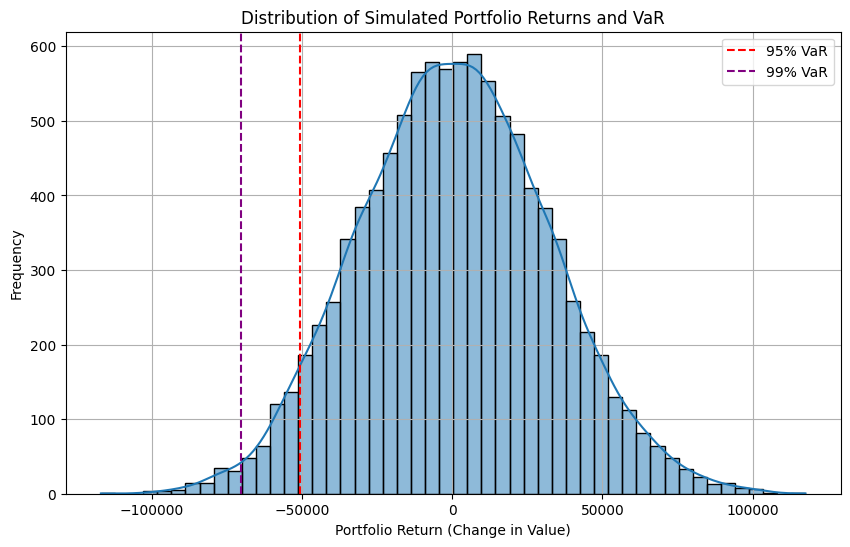

In [25]:
# Monte Carlo Simulation for VaR

num_simulations = 10000
time_horizon = 1/365.25 # 1 day in years (for 1-day VaR)

# Estimate volatility of the underlying (NIFTY) from implied volatilities
# For simplicity, let's use the average Call Implied Volatility from our cleaned data
underlying_volatility = nifty_df_clean['Call_Implied_Volatility'].mean()

portfolio_values_simulated = []

for _ in range(num_simulations):
    # Simulate future spot price using Geometric Brownian Motion
    # dS = S * (mu * dt + sigma * dW)
    # S_t = S_0 * exp((mu - 0.5 * sigma^2) * dt + sigma * sqrt(dt) * Z)
    # For short dt, we can approximate mu with r (risk-neutral pricing)
    drift = (r - 0.5 * underlying_volatility**2) * time_horizon
    random_shock = underlying_volatility * np.sqrt(time_horizon) * np.random.normal(0, 1)

    simulated_spot_price = current_spot_price_demo * np.exp(drift + random_shock)

    # Calculate portfolio value with the simulated spot price
    simulated_portfolio_value = get_portfolio_value(portfolio_df, simulated_spot_price, r)
    portfolio_values_simulated.append(simulated_portfolio_value)

# Convert to a Series for easier calculation of VaR
portfolio_returns = pd.Series(portfolio_values_simulated) - initial_portfolio_value

# Calculate VaR at different confidence levels
confidence_levels = [0.95, 0.99]
VaR_results = {}

print("\n--- Value at Risk (VaR) Results ---")
for confidence_level in confidence_levels:
    # VaR is the negative of the percentile of the loss distribution
    var_val = -np.percentile(portfolio_returns, (1 - confidence_level) * 100)
    VaR_results[f'VaR_{int(confidence_level*100)}%'] = var_val
    print(f"1-Day {int(confidence_level*100)}% VaR: {var_val:.2f}")

# Visualize the distribution of simulated portfolio returns
plt.figure(figsize=(10, 6))
import seaborn as sns
sns.histplot(portfolio_returns, bins=50, kde=True)
plt.axvline(x=-VaR_results['VaR_95%'], color='r', linestyle='--', label='95% VaR')
plt.axvline(x=-VaR_results['VaR_99%'], color='purple', linestyle='--', label='99% VaR')
plt.title('Distribution of Simulated Portfolio Returns and VaR')
plt.xlabel('Portfolio Return (Change in Value)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()